In [7]:
import utils
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
import pefile
import numpy as np

mpl.rcParams["figure.dpi"] = 300

dataset = utils.data.MalwareDataset()

In [ ]:
import os


def get_size(path):
    try:
        # pe = pefile.PE(path, fast_load=True)
        # size = pe.dump_dict()["OPTIONAL_HEADER"]["SizeOfCode"]["Value"]
        return os.path.getsize(path)
    except:
        return 0

In [9]:
malware_size = []
benign_size = []

for path, label in tqdm(dataset):
    size = get_size(path)
    if label == 0:
        benign_size.append(size)
    else:
        malware_size.append(size)

100%|██████████| 11115/11115 [00:00<00:00, 19254.72it/s]


In [10]:
malware_size = np.array(malware_size)
benign_size = np.array(benign_size)

print(f"Min: {malware_size.min()}, Max: {malware_size.max()}, No: {len(malware_size)}")
print(f"Min: {benign_size.min()}, Max: {benign_size.max()}, No: {len(benign_size)}")

Min: 925, Max: 11485523, No: 5792

Min: 0, Max: 1105855970, No: 5323

In [11]:
import pandas as pd

df = pd.DataFrame(
    {
        "label": [0] * len(benign_size) + [1] * len(malware_size),
        "size": np.array(benign_size.tolist() + malware_size.tolist()) / (1024**2),
    }
)

Text(0.5, 0, 'Executable Kind')

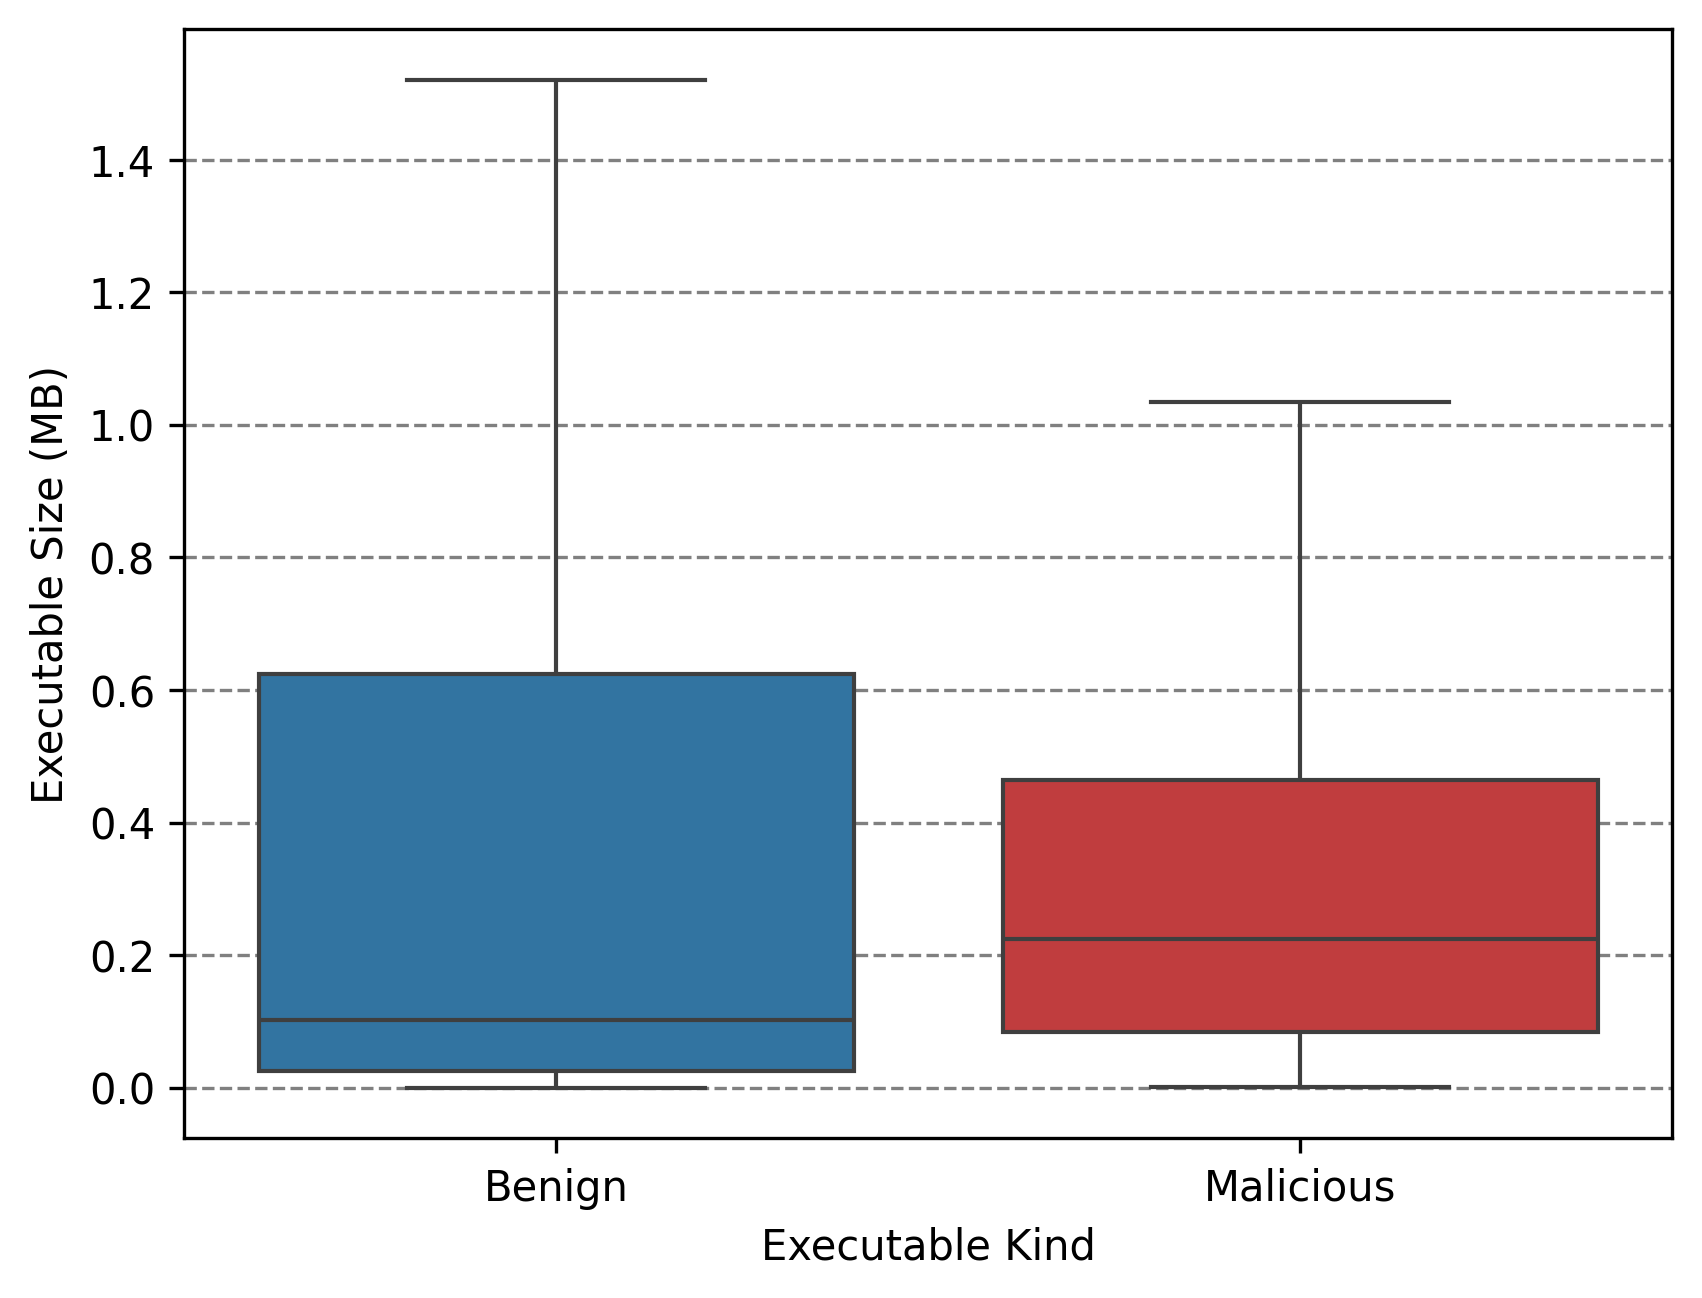

In [12]:
import seaborn as sns

fig, ax = plt.subplots(dpi=300)

sns.boxplot(
    data=df,
    x="label",
    hue="label",
    palette={
        np.int64(0): "tab:blue",
        np.int64(1): "tab:red",
    },
    y="size",
    showfliers=False,
    formatter=lambda l: "Benign" if l == 0 else "Malicious",
    # log_scale=True,
    legend=False,
    ax=ax,
)
ax.grid(True, axis="y", linestyle="--", c="grey")
ax.set_ylabel("Executable Size (MB)")
ax.set_xlabel("Executable Kind")